In [1]:
!hostnamectl

 Static hostname: gpue02.delta.ncsa.illinois.edu
       Icon name: computer-server
         Chassis: server 🖳
      Machine ID: 7160fa58ed57460fad63c00d1f2ce1bc
         Boot ID: 03b8ad4d5da846abbb331a11f6309515
Operating System: ]8;;https://www.redhat.com/Red Hat Enterprise Linux 9.4 (Plow)]8;;     
     CPE OS Name: cpe:/o:redhat:enterprise_linux:9::baseos
          Kernel: Linux 5.14.0-427.91.1.el9_4.x86_64
    Architecture: x86-64
Firmware Version: CUXD670_5.32_v2.06


In [ ]:
# # Check JAX sees the GPU
# import jax
# print(jax.devices())  # should show CudaDevice(id=0)
# print(jax.default_backend())  # should show 'gpu'

# # Check CUDA version
# import subprocess
# print(subprocess.run(['nvidia-smi'], capture_output=True, text=True).stdout)

# # Check JAX/jaxlib versions
# import jaxlib
# print(f"JAX version: {jax.__version__}")
# print(f"jaxlib version: {jaxlib.__version__}")

# # Quick GPU computation test
# import jax.numpy as jnp
# x = jnp.ones((1000, 1000))
# print(f"Array device: {x.devices()}")  # should show CudaDevice

In [2]:
# tmp 
import os
tmp_dir = '/projects/bgdb/asachan/datasets/SKM_ageing_human/tmp'
os.environ["XLA_FLAGS"] = "--xla_gpu_force_compilation_parallelism=8"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# Cache compiled kernels to disk (create this directory first)
cache_dir = os.path.join(tmp_dir, "asachan_jax_cache")
os.makedirs(cache_dir, exist_ok=True)
os.environ["JAX_COMPILATION_CACHE_DIR"] = cache_dir

In [3]:
import os
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

import moscot as mt
import moscot.plotting as mpl
from moscot.problems.time import TemporalProblem

In [4]:
import os
os.chdir("/projects/bgdb/asachan/methods/OT_FM")  # adjust path if needed
from utils import *

In [5]:
plt.rcParams["legend.scatterpoints"] = 1
sc.set_figure_params(scanpy=True, dpi=80, dpi_save=200)

warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", FutureWarning)

In [12]:
rna_path = '/projects/bgdb/asachan/datasets/SKM_ageing_human/musc_transition_old_male.h5ad'
rna_path_filtered = '/projects/bgdb/asachan/datasets/SKM_ageing_human/filtered_all_cell_types.h5ad'

In [13]:
rna_adata = sc.read_h5ad(rna_path)
rna_adata

AnnData object with n_obs × n_vars = 3942 × 48355
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation', 'age_sex', 'intervals_old'
    obsm: 'UMAP_1st', 'X_pca', 'X_pca_harmony', 'X_umap'

# MuSC to type1/2 transitions

In [ ]:
#subset to cell types of interest
rna_adata = rna_adata[rna_adata.obs['Annotation'].isin(['MuSC', 'Type II', 'Type I', 'Specialized MF'])].copy()

In [ ]:
rna_adata.obs['age_sex'] = (
    rna_adata.obs['age'].astype('float').astype(int).astype(str)
    + '_' + 
    rna_adata.obs['Sex'].astype(str)
)
rna_adata.obs['age_sex'].value_counts().sort_index()

In [ ]:
# Define interval mappings
interval_map = {
    # Male intervals
    '15_Male': 'interval_1_M',
    '18_Male': 'interval_1_M',
    '34_Male': 'interval_2_M',
    '38_Male': 'interval_2_M',
    '45_Male': 'interval_2_M',
    # Female intervals
    '17_Female': 'interval_1_F',
    '29_Female': 'interval_1_F',
    '34_Female': 'interval_2_F',
}

rna_adata.obs['intervals_young'] = rna_adata.obs['age_sex'].map(interval_map)
# unmapped values will be NaN — replace with 'other' or leave as NaN
# rna_adata.obs['age_sex_interval'] = rna_adata.obs['age_sex_interval'].fillna('other')

# Verify
rna_adata.obs['intervals_young'].value_counts()

In [ ]:
# Define interval mappings
interval_map = {
    # Male intervals
    '77_Male': 'interval_1_M',
    '79_Male': 'interval_1_M',
    '82_Male': 'interval_1_M',
    '84_Male': 'interval_1_M',
    '85_Male': 'interval_2_M',
    '88_Male': 'interval_2_M',
    # Female intervals
    '79_Female': 'interval_1_F',
    '80_Female': 'interval_1_F',
    '82_Female': 'interval_1_F',
    '84_Female': 'interval_2_F',
    '89_Female': 'interval_2_F',
    '92_Female': 'interval_2_F',
    '99_Female': 'interval_2_F'
}

rna_adata.obs['intervals_old'] = rna_adata.obs['age_sex'].map(interval_map)
# unmapped values will be NaN — replace with 'other' or leave as NaN
# rna_adata.obs['age_sex_interval'] = rna_adata.obs['age_sex_interval'].fillna('other')

rna_adata.obs['intervals_old'].value_counts()

In [ ]:
mask = (
    # interval_1: MuSC only
    (rna_adata.obs['intervals_old'].isin(['interval_1_M', 'interval_1_F']) & 
     (rna_adata.obs['Annotation'] == 'MuSC'))
    |
    # interval_2: Type II, Type I, Specialized MF only (no MuSC)
    (rna_adata.obs['intervals_old'].isin(['interval_2_M', 'interval_2_F']) & 
     rna_adata.obs['Annotation'].isin(['Type II', 'Type I', 'Specialized MF']))
)

rna_adata = rna_adata[mask].copy()

# Verify — should show no MuSC in interval_2 and no other types in interval_1
rna_adata.obs.groupby(['intervals_old', 'Annotation']).size()

In [ ]:
n_cells_downsample = 2000
adatas = []

for interval, idx in rna_adata.obs.groupby('intervals_old').groups.items():
    subset = rna_adata[idx].copy()
    
    if interval.startswith('interval_2') and subset.shape[0] > n_cells_downsample:
        sc.pp.sample(subset, n=n_cells_downsample, copy=False, rng=42)
    
    adatas.append(subset)

rna_adata = ad.concat(adatas)
del adatas

print(rna_adata.obs['intervals_old'].value_counts())

In [ ]:
# subset adata to male and female cells based on intervals_young
rna_adata_male = rna_adata[rna_adata.obs['intervals_old'].isin(['interval_1_M', 'interval_2_M'])].copy()
rna_adata_female = rna_adata[rna_adata.obs['intervals_old'].isin(['interval_1_F', 'interval_2_F'])].copy()

In [ ]:
rna_adata_female.obs

In [ ]:

import anndata as ad
ad.settings.allow_write_nullable_strings = True
# save
rna_adata_male.write_h5ad('/projects/bgdb/asachan/datasets/SKM_ageing_human/musc_transition_old_male.h5ad')
rna_adata_female.write_h5ad('/projects/bgdb/asachan/datasets/SKM_ageing_human/musc_transition_old_female.h5ad')

#### subset to young and old transitions (separately)

In [ ]:
#young_adata = rna_adata[rna_adata.obs['sample'] == 'YM3'].copy()
#old_adata = rna_adata[rna_adata.obs['sample'] == 'YM2'].copy()


In [ ]:
# subset to samples of interest
#rna_adata = rna_adata[rna_adata.obs['sample'].isin(['P26', 'YM2', 'OM6', 'OM9', 'P13', 'P5', 'OM5', 'OM7'])].copy()

In [ ]:
adata = rna_adata_female

In [ ]:
#subset to cell types of interest
rna_adata = rna_adata[rna_adata.obs['Annotation'].isin(['Type II', 'Type I', 'MuSC', 'Specialized MF'])].copy()
#rna_adata = rna_adata[rna_adata.obs['Annotation'].isin(['Type II'])].copy()

#### Lower bound on number of cells per age

In [ ]:
# age_counts = rna_adata.obs['age'].value_counts()
# valid_ages = age_counts[age_counts >= 500].index

# rna_adata = rna_adata[rna_adata.obs['age'].isin(valid_ages)].copy()

# # # Verify
# print(rna_adata.obs['age'].value_counts())

#### Upper bound on number of cells per age

In [ ]:
# n_cells_downsample = 5000
# adatas = []

# for age, idx in rna_adata.obs.groupby('age').groups.items():
#     subset = rna_adata[idx].copy()
#     if subset.shape[0] > n_cells_downsample:
#         sc.pp.sample(subset, n=n_cells_downsample, copy=False, rng=42)
#     adatas.append(subset)

# rna_adata = ad.concat(adatas)
# del adatas

# # Verify
# print(rna_adata.obs['age'].value_counts())

In [ ]:
rna_adata.obs

In [ ]:
# #load adata with sub cluster labels
# type2_sub_cluster = sc.read_h5ad('/projects/bgdb/asachan/datasets/SKM_ageing_human/Myofiber_scsn_RNA.h5ad')
# type2_sub_cluster

In [ ]:
# type2_sub_cluster.obs['Annotation'].value_counts()

In [ ]:
# subset_adata = type2_sub_cluster[type2_sub_cluster.obs['Annotation'].isin(['Type II', 'ENOX1+ (II)', 'ID1+ (II)', 'SAA2+ (II)', 'DCLK1+ (II)', 'TNNT2+ (II)'])]

In [ ]:
# # save 
#rna_adata.write_h5ad('/projects/bgdb/asachan/datasets/SKM_ageing_human/type2_samples_oi.h5ad')

In [ ]:
display(rna_adata.obs['Annotation'].value_counts())
print(rna_adata.obs["Annotation"].unique())

## Instantiate OT

In [14]:
rna_adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,sample,percent.mt,age,tech,Sex,Country,age_pop,Annotation,age_sex,intervals_old
CELL300_N1_1_1_1_9_1,P29_1,2322.101630,1357,P29,0.000000,77.0,snRNA,Male,Spain,old_pop,MuSC,77_Male,interval_1_M
CELL153_N1_1_1_1_9_1,P29_1,2904.376876,1806,P29,0.065700,77.0,snRNA,Male,Spain,old_pop,MuSC,77_Male,interval_1_M
CELL113_N1_1_1_1_9_1,P29_1,3597.024773,1885,P29,0.004582,77.0,snRNA,Male,Spain,old_pop,MuSC,77_Male,interval_1_M
CELL359_N1_1_1_1_9_1,P29_1,2064.835068,1199,P29,0.025864,77.0,snRNA,Male,Spain,old_pop,MuSC,77_Male,interval_1_M
CELL459_N1_1_1_1_9_1,P29_1,1844.681312,1100,P29,0.188324,77.0,snRNA,Male,Spain,old_pop,MuSC,77_Male,interval_1_M
...,...,...,...,...,...,...,...,...,...,...,...,...,...
CELL162_N1_2_1_2_1_1_9_1,P23_4,1884.202337,725,P23,0.327228,85.0,snRNA,Male,Spain,old_pop,Type I,85_Male,interval_2_M
CELL642_N1_1_1_1_1_1_1_1_9_1,P17_1,1138.769831,626,P17,0.231768,88.0,snRNA,Male,Spain,old_pop,Type II,88_Male,interval_2_M
CELL2174_N1_1_1_2_1_1_9_1,P23_3,1311.506361,543,P23,1.390646,85.0,snRNA,Male,Spain,old_pop,Type II,85_Male,interval_2_M
CELL141_N1_2_1_2_1_1_9_1,P23_4,1980.857967,690,P23,0.017484,85.0,snRNA,Male,Spain,old_pop,Type I,85_Male,interval_2_M


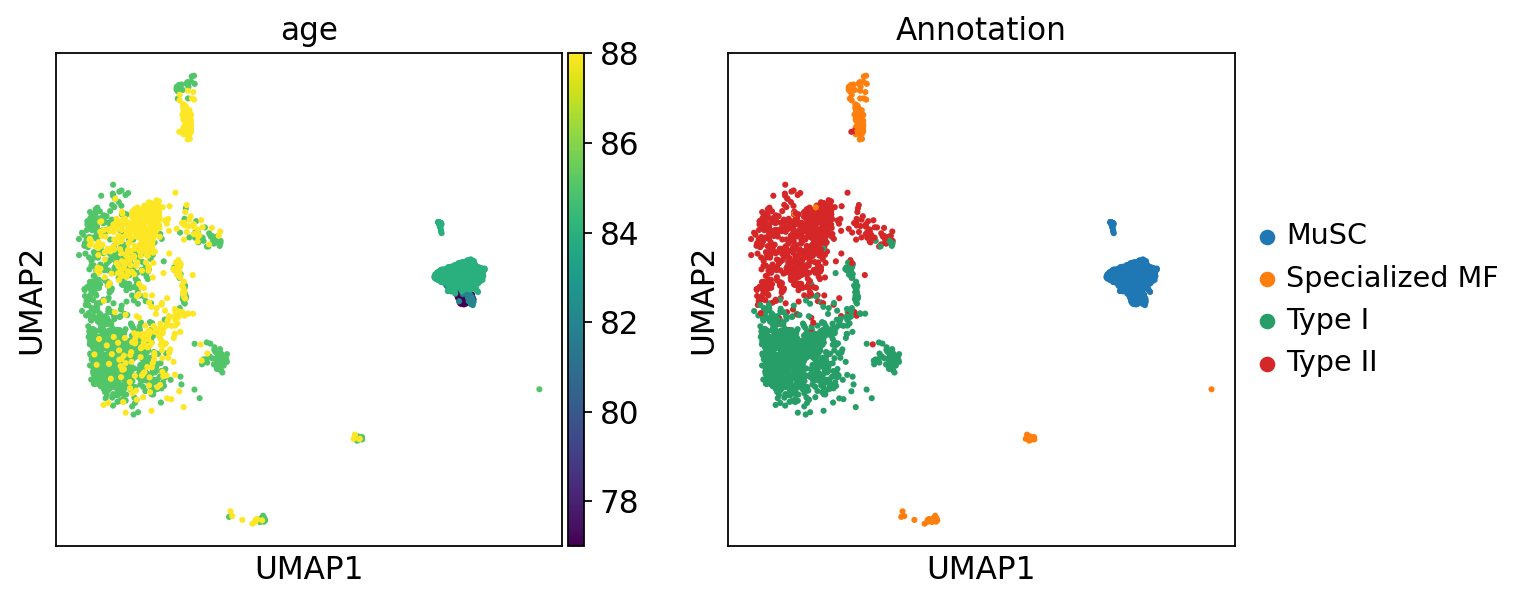

In [15]:
sc.pl.umap(rna_adata, color=['age', 'Annotation'])

In [16]:
# make temporal info numeric
def adapt_time(x):
    if x["intervals_old"] in ["interval_1_M"]:
        return 1.5
    if x["intervals_old"] in ["interval_2_M"]:
        return 3.5
    raise ValueError
    
rna_adata.obs["intervals_old"] = rna_adata.obs.apply(adapt_time, axis=1).astype("category")

In [17]:
# instantiate temporal OT problem
tp0 = TemporalProblem(rna_adata)
tp0 = tp0.prepare(time_key="intervals_old")

INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  


In [18]:
import networkx as nx

batch_column = "intervals_old"
batch1, batch2 = 1.5, 3.5

indices = np.where(
    (rna_adata.obs[batch_column] == batch1) | (rna_adata.obs[batch_column] == batch2)
)[0]

adata_subset = rna_adata[indices]
sc.pp.neighbors(adata_subset, n_neighbors=30, use_rep="X_pca")

G = nx.from_numpy_array(adata_subset.obsp["connectivities"].todense())
assert nx.is_connected(G)

In [19]:
#if graph not connect check if there is a major disconnectivity due to batch effect in the latent space
n_components = nx.number_connected_components(G)
print(f"Number of connected components: {n_components}")
# Check sizes of each component
sizes = sorted([len(c) for c in nx.connected_components(G)], reverse=True)
print(f"Component sizes: {sizes}")

Number of connected components: 1
Component sizes: [3942]


In [20]:
df = pd.DataFrame(
    index=adata_subset.obs_names,
    columns=adata_subset.obs_names,
    data=adata_subset.obsp["connectivities"].todense().astype("float"),
)

In [21]:
t1, t2 = 1.5, 3.5
prob = tp0[t1, t2]
expected = prob.adata_src.obs_names.append(prob.adata_tgt.obs_names)
Gdf = df.loc[expected, expected].astype(float)
prob.set_graph_xy(Gdf, t=100.0)

In [22]:
import scanpy as sc
sc.settings.verbosity = 3  # shows more detail
# epsilon: entropic regularization strength
#batch_size is for sinkhorn iterations, the grpah omputation and transfer to gpu (compilation) takes most time
tp0 = tp0.solve(epsilon=1e-3, scale_cost="mean", max_iterations=1e7) 

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(1942, 2000)].                                  


W0316 05:15:09.252706  178653 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 05:15:23.890464  178653 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 05:15:24.568201  178653 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 05:15:25.925455  178653 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 05:15:26.143275  178653 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 05:15:27.104313  178653 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 05:15:30.162950  182298 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 05:15:30.166059  182297 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 05

### Save objects after computation

In [23]:
import cloudpickle
with open(f'{tmp_dir}/musc_transition_old_male.pkl', 'wb') as f:
    cloudpickle.dump(tp0, f)
print("Saved!")

Saved!


In [24]:
import numpy as np
import scipy.sparse as sp

T_15_35 = tp0[1.5, 3.5].solution.transport_matrix

# JAX -> NumPy
T_15_35_np = np.asarray(T_15_35)

# NumPy -> sparse (CSR)
T_15_35_csr = sp.csr_matrix(T_15_35_np)

sp.save_npz(os.path.join(tmp_dir, "T_1.5_3.5_musc_transition_old_male.npz"), T_15_35_csr)

W0316 05:16:43.352667  178653 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 05:16:43.374542  178653 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 05:16:43.396414  178653 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 05:16:43.450275  178653 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 05:16:43.522640  178653 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 05:16:43.561265  178653 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 05:16:43.601496  178653 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 05:16:43.640462  178653 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.


## Visualize cell clusters of interest

In [25]:
rna_adata.obs["Annotation"] = rna_adata.obs["Annotation"].astype("category")
order_cell_types = rna_adata.obs["Annotation"].cat.categories.tolist()
order_cell_types

['MuSC', 'Specialized MF', 'Type I', 'Type II']

W0316 05:16:52.530087  178653 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 05:16:52.582053  178653 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 05:16:52.654982  178653 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 05:16:52.698680  178653 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 05:16:52.742789  178653 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 05:16:52.783178  178653 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 05:16:52.804530  178653 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 05:16:52.846108  178653 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 05

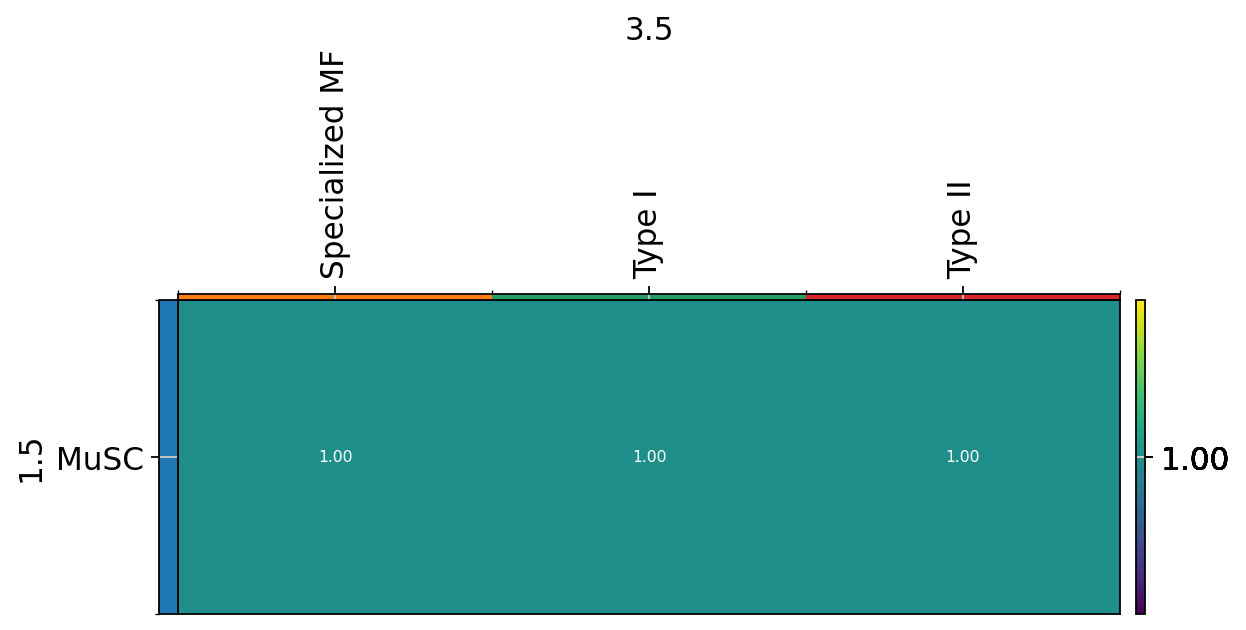

In [26]:
#aggregating the transport matrix by bins of interest
# ANSCESTORS

ct_desc = tp0.cell_transition(
    1.5,
    3.5,
    {"Annotation": order_cell_types},
    {"Annotation": order_cell_types},
    forward=False,
    key_added="transitions_1.5_3.5_large",
)

fig, ax = plt.subplots(figsize=(8, 6))
mpl.cell_transition(
    tp0,
    fontsize=7,
    figsize=(8, 6),
    return_fig=True,
    ax=ax,
    key="transitions_1.5_3.5_large",
)
plt.tight_layout()
plt.show()

W0316 05:16:58.180674  178653 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 05:16:58.206363  178653 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 05:16:58.256081  178653 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 05:16:58.300101  178653 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 05:16:58.380621  178653 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 05:16:58.425304  178653 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 05:16:58.465352  178653 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 05:16:58.485976  178653 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 05

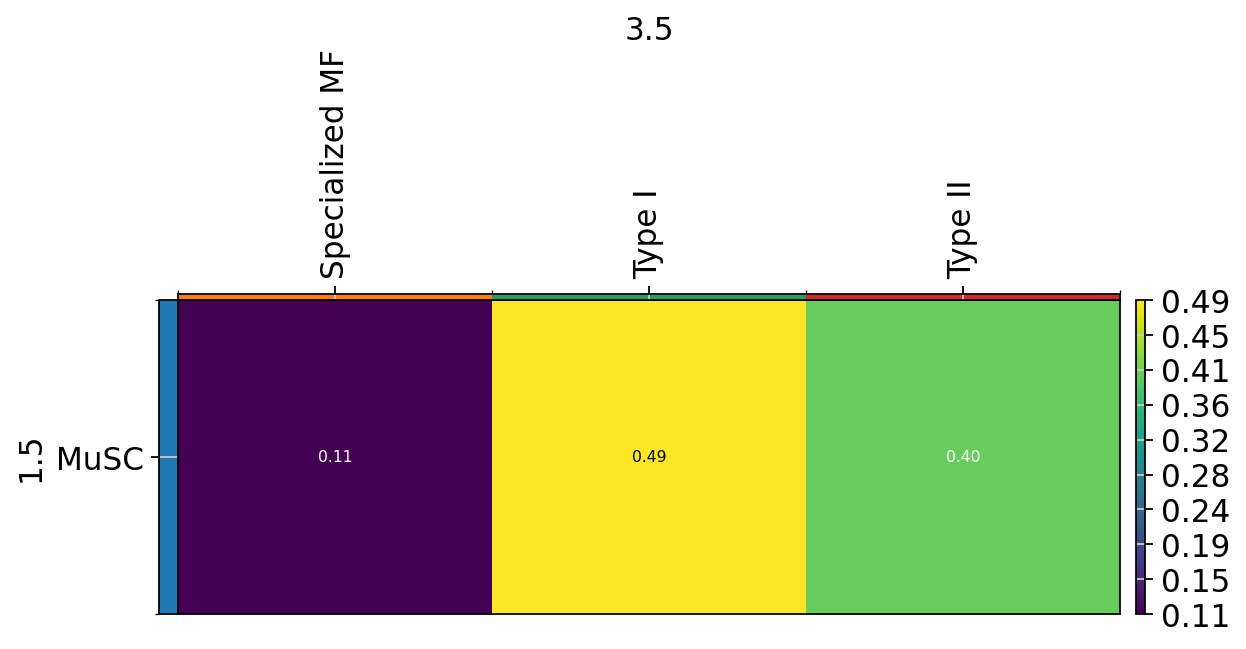

In [27]:
#aggregating the transport matrix by chronological age
# DESCENDANTS

ct_desc = tp0.cell_transition(
    1.5,
    3.5,
    {"Annotation": order_cell_types},
    {"Annotation": order_cell_types},
    forward=True,
    key_added="transitions_1.5_3.5_soi",
)

fig, ax = plt.subplots(figsize=(8, 6))
mpl.cell_transition(
    tp0,
    fontsize=7,
    figsize=(8, 6),
    return_fig=True,
    ax=ax,
    key="transitions_1.5_3.5_soi",
)
plt.tight_layout()
plt.show()

In [28]:
tp0.sankey(
    source=1.5,
    target=3.5,
    source_groups={"Annotation": order_cell_types},
    target_groups={"Annotation": order_cell_types},
    threshold=0.05,
    order_annotations=order_cell_types[::-1],
    normalize=True,
)

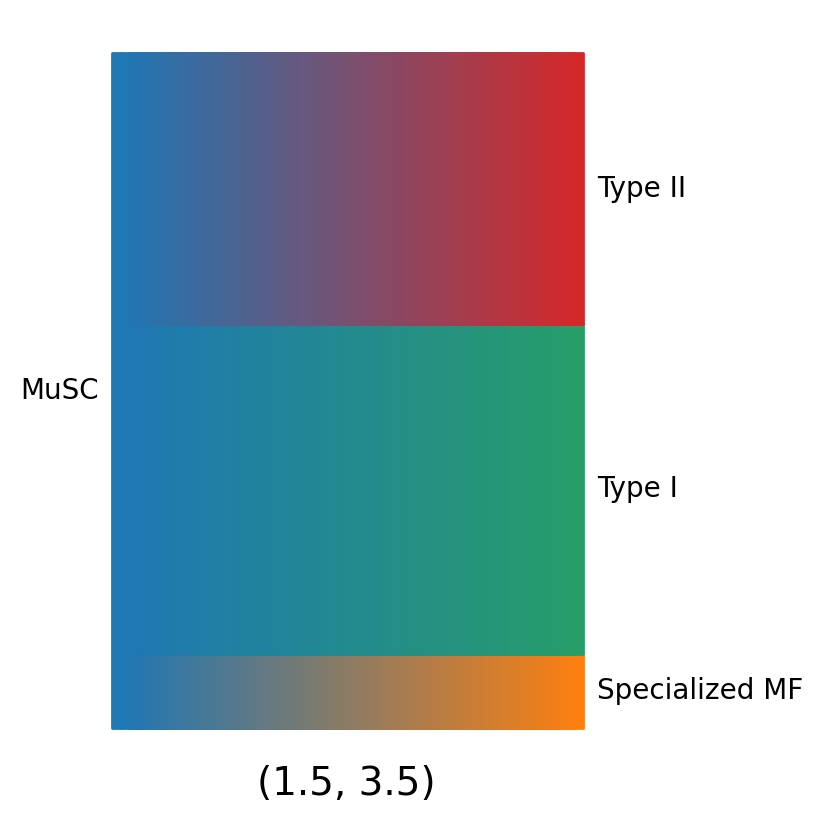

In [29]:
mpl.sankey(tp0, dpi=100, figsize=(4, 4), fontsize=10, interpolate_color=True)

## Identifying driver genes

In [30]:
X_orig = tp0.adata.X.copy()

#check mean and min and max of X
print(X_orig.mean(), X_orig.min(), X_orig.max())

0.04408188 0.0 8.64284


In [31]:
sc.pp.normalize_total(tp0.adata)
sc.pp.log1p(tp0.adata)

normalizing counts per cell
    finished (0:00:00)


In [32]:
tp0.adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,sample,percent.mt,age,tech,Sex,Country,age_pop,Annotation,age_sex,intervals_old
CELL300_N1_1_1_1_9_1,P29_1,2322.101630,1357,P29,0.000000,77.0,snRNA,Male,Spain,old_pop,MuSC,77_Male,1.5
CELL153_N1_1_1_1_9_1,P29_1,2904.376876,1806,P29,0.065700,77.0,snRNA,Male,Spain,old_pop,MuSC,77_Male,1.5
CELL113_N1_1_1_1_9_1,P29_1,3597.024773,1885,P29,0.004582,77.0,snRNA,Male,Spain,old_pop,MuSC,77_Male,1.5
CELL359_N1_1_1_1_9_1,P29_1,2064.835068,1199,P29,0.025864,77.0,snRNA,Male,Spain,old_pop,MuSC,77_Male,1.5
CELL459_N1_1_1_1_9_1,P29_1,1844.681312,1100,P29,0.188324,77.0,snRNA,Male,Spain,old_pop,MuSC,77_Male,1.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
CELL162_N1_2_1_2_1_1_9_1,P23_4,1884.202337,725,P23,0.327228,85.0,snRNA,Male,Spain,old_pop,Type I,85_Male,3.5
CELL642_N1_1_1_1_1_1_1_1_9_1,P17_1,1138.769831,626,P17,0.231768,88.0,snRNA,Male,Spain,old_pop,Type II,88_Male,3.5
CELL2174_N1_1_1_2_1_1_9_1,P23_3,1311.506361,543,P23,1.390646,85.0,snRNA,Male,Spain,old_pop,Type II,85_Male,3.5
CELL141_N1_2_1_2_1_1_9_1,P23_4,1980.857967,690,P23,0.017484,85.0,snRNA,Male,Spain,old_pop,Type I,85_Male,3.5


In [34]:
# Get driver TFs for age-chronological_young/cell-cluster-2 (young) → age-chronological_old/cell-cluster-1 (old) transition
drivers_spec, top_pos, top_neg = driver_tfs_for_subset(
    tp=tp0,
    old_cell_cluster='Type I',
    young_cell_cluster='MuSC',
    cell_cluster_col='Annotation',
    timepoint_col='intervals_old',
    t_young=1.5,
    t_old=3.5,
)

[pull] key='Type I_MuSC_pull' | weight sum = 2.0000
[subset] 1942 cells with Annotation=MuSC at t=1.5
count    1.942000e+03
mean     5.149328e-04
std      2.607605e-04
min      1.651251e-23
25%      3.771294e-04
50%      6.431306e-04
75%      7.008369e-04
max      1.045003e-03
Name: Type I_MuSC_pull, dtype: float64

[result] 70 significant drivers (qval<0.05, |corr|>0.1)


,Type I_MuSC_corr,Type I_MuSC_pval,Type I_MuSC_qval,Type I_MuSC_ci_low,Type I_MuSC_ci_high,significant
ATF3,0.199182,0.000000,0.000000,0.169014,0.228977,True
UBB,0.188548,0.000000,0.000000,0.158261,0.218481,True
NR4A1,0.185649,0.000000,0.000000,0.155331,0.215618,True
LRRFIP1,0.181684,0.000000,0.000000,0.151324,0.211702,True
ID1,0.177444,0.000000,0.000000,0.147040,0.207513,True
JUNB,0.173306,0.000000,0.000000,0.142861,0.203424,True
RPS4X,0.170931,0.000000,0.000000,0.140462,0.201077,True
PDLIM5,0.167816,0.000000,0.000000,0.137317,0.197998,True
ID2,0.164675,0.000000,0.000000,0.134146,0.194892,True
H2AFZ,0.164262,0.000000,0.000000,0.133729,0.194483,True


,Type I_MuSC_corr,Type I_MuSC_pval,Type I_MuSC_qval,Type I_MuSC_ci_low,Type I_MuSC_ci_high,significant
MDM2,-0.257283,0.000000,0.000000,-0.286203,-0.227895,True
RUNX1,-0.171184,0.000000,0.000000,-0.201327,-0.140717,True
FOXO1,-0.165489,0.000000,0.000000,-0.195696,-0.134967,True
ZEB2,-0.151481,0.000000,0.000000,-0.181840,-0.120834,True
ZBTB20,-0.150504,0.000000,0.000000,-0.180872,-0.119848,True
RB1,-0.127348,0.000000,0.000000,-0.157938,-0.096513,True
RPS6KA5,-0.118931,0.000000,0.000000,-0.149594,-0.088039,True
ZBTB7C,-0.117514,0.000000,0.000000,-0.148189,-0.086613,True
ESR1,-0.112809,0.000000,0.000000,-0.143522,-0.081879,True
ZNF438,-0.108851,0.000000,0.000000,-0.139595,-0.077897,True
